In [ ]:
#Performs necessary imports
import pandas as pd
import os
import numpy as np
import itertools
from collections import Counter


In [ ]:
cycles = input('How many federal election cycles would you like to analyze, starting from 2020 and going back? Please enter a number from 1-6 ')
maxbalance = input('What is the maximum balance that you would like these subsets of states to have? Keep this number large for initial analysis')
cycles = int(cycles.strip())
maxbalance = int(maxbalance.strip())
max_balchange = int(input('What is the maximum amount of balance-change you would allow for these subsets of states? Keep this number large for initial analysis. '))
comb_max = int(input('What is the maximum number of states to be included in each combination? Please enter a number from 3-5 '))

How many federal election cycles would you like to analyze, starting from 2020? Please enter a number from 1-6 6
What is the maximum balance that you would like these subsets of states to have?1000
What is the maximum amount of balance-change you would allow for these subsets of states? Please answer with just a number. 10000
What is the maximum number of states to be included in each combination? Please enter a number from 3-5 5


In [ ]:
#Reads data from a public file containing the data from the past 6 elections
#Changed the vote allocation system to hamilton/largest remainder method to avoid rounding problems
#file_path = 'https://adityagarg9.github.io/Voter-Realignment-Data/VoterRealignmentData.csv'

#electiondata = pd.read_csv(file_path).fillna(0)
electiondata = pd.read_csv('election_data_2000_2024.csv').fillna(0)
#electiondata.head()

electiondata['sum_voters'] = electiondata[['POPULAR VOTE: D', 'POPULAR VOTE: R']].sum(axis=1) #Creates a column with the total number of votes for later divion purposes

electiondata['DEMOCRAT PERCENTAGE'] = ((electiondata['POPULAR VOTE: D']/(electiondata['sum_voters']))*100) #Calculates the percentage of these votes won by the democrats

electiondata['REPUBLICAN PERCENTAGE'] = ((electiondata['POPULAR VOTE: R']/(electiondata['sum_voters']))*100) #Calculates the percentage of these votes won by the republicans

electiondata['TOTAL ELECTORAL VOTES FOR EACH STATE'] = (electiondata['TOTAL ELECTORAL VOTES: D'] + electiondata['TOTAL ELECTORAL VOTES: R']) #Calculates the total electoral votes for each state to later help determine the change from winner-take-all to proportional.

# Exact (unrounded) electoral-vote quota each party has earned in the state.
# Note the /100: DEMOCRAT PERCENTAGE is on a 0-100 scale, so we convert back to a share first.
electiondata['q_dem'] = (electiondata['DEMOCRAT PERCENTAGE']   / 100) * electiondata['TOTAL ELECTORAL VOTES FOR EACH STATE'] #Calculates the number
electiondata['q_rep'] = (electiondata['REPUBLICAN PERCENTAGE'] / 100) * electiondata['TOTAL ELECTORAL VOTES FOR EACH STATE'] #Calculates the number

# Largest-remainder (Hamilton) allocation, done vectorially across all rows.
# Give each party the whole votes it clearly earned (the floor of its quota)...
f_dem = np.floor(electiondata['q_dem']).astype(int)
f_rep = np.floor(electiondata['q_rep']).astype(int)

# ...then work out the single leftover vote (0 or 1 for two parties).
total_ev  = electiondata['TOTAL ELECTORAL VOTES FOR EACH STATE'].round().astype(int)
remaining = total_ev - f_dem - f_rep     # 0 or 1 for two parties

# leftover seat goes to the larger fractional remainder (ties -> D)
dem_gets_leftover = (remaining > 0) & ((electiondata['q_dem'] - f_dem) >= (electiondata['q_rep'] - f_rep))

electiondata['DEMOCRAT REALLOCATED']   = f_dem + np.where(dem_gets_leftover, remaining, 0) #Reallocates the electoral votes for the democrats from winner-take-all to proportional based on popular vote percentage.

electiondata['REPUBLICAN REALLOCATED'] = f_rep + np.where((remaining > 0) & ~dem_gets_leftover, remaining, 0) #Reallocates the electoral votes for the republicans from winner-take-all to proportional based on popular vote percentage.

electiondata['DEMOCRAT CHANGE'] = electiondata['DEMOCRAT REALLOCATED'] - electiondata['TOTAL ELECTORAL VOTES: D'] #Calculates the change in electoral votes for democrats for each state from the winner-take-all system to the proportional system

electiondata['REPUBLICAN CHANGE'] = electiondata['REPUBLICAN REALLOCATED'] - electiondata['TOTAL ELECTORAL VOTES: R'] #Calculates the change in electoral votes for republicans for each state from the winner-take-all system to the proportional system

electiondata.head()

,YEAR,STATE,TOTAL ELECTORAL VOTES: D,TOTAL ELECTORAL VOTES: R,POPULAR VOTE: D,POPULAR VOTE: R,POPULAR VOTE: All Others,sum_voters,DEMOCRAT PERCENTAGE,REPUBLICAN PERCENTAGE,TOTAL ELECTORAL VOTES FOR EACH STATE,q_dem,q_rep,DEMOCRAT REALLOCATED,REPUBLICAN REALLOCATED,DEMOCRAT CHANGE,REPUBLICAN CHANGE
0,2020,CA,55.0,0.0,11110639,6006518,384223,17117157,64.909371,35.090629,55.0,35.700154,19.299846,36,19,-19.0,19.0
1,2020,NY,29.0,0.0,5244886,3251997,119978,8496883,61.727177,38.272823,29.0,17.900881,11.099119,18,11,-11.0,11.0
2,2020,PA,20.0,0.0,3458229,3377674,101073,6835903,50.589205,49.410795,20.0,10.117841,9.882159,10,10,-10.0,10.0
3,2020,GA,16.0,0.0,2473633,2461854,64473,4935487,50.119330,49.880670,16.0,8.019093,7.980907,8,8,-8.0,8.0
4,2020,IL,20.0,0.0,3471915,2446891,114938,5918806,58.659044,41.340956,20.0,11.731809,8.268191,12,8,-8.0,8.0


In [ ]:
#This dataframe gives an overview of the cycles
dem_total = electiondata.groupby('YEAR')['TOTAL ELECTORAL VOTES: D'].sum().reset_index()

dem_total.columns = ['YEAR', 'TOTAL_DEM_VOTES']

rep_total = electiondata.groupby('YEAR')['TOTAL ELECTORAL VOTES: R'].sum().reset_index()

rep_total.columns = ['YEAR', 'TOTAL_REP_VOTES']

popular_d = electiondata.groupby('YEAR')['POPULAR VOTE: D'].sum().reset_index()

popular_r = electiondata.groupby('YEAR')['POPULAR VOTE: R'].sum().reset_index()

allothers = electiondata.groupby('YEAR')['POPULAR VOTE: All Others'].sum().reset_index()

merged_df = dem_total.merge(rep_total, on='YEAR')\
                     .merge(popular_d, on='YEAR')\
                     .merge(popular_r, on='YEAR')\
                     .merge(allothers, on='YEAR')

merged_df['DIFF'] = (merged_df['TOTAL_DEM_VOTES'] - merged_df['TOTAL_REP_VOTES'])

merged_df['WINNER'] = np.where(merged_df['DIFF'] > 0, 'D', 'R')

merged_df['VOTES_TO_WIN'] = ((merged_df['DIFF'].abs())/2)+1

merged_df['VOTES_TO_WIN'] = np.floor(merged_df['VOTES_TO_WIN'] * 1) / 1

orig_pres_results = merged_df
merged_df.head(10)

#Makes a new dataframe, showing how many electoral votes each part had after reallocation
new_dem_total = electiondata.groupby('YEAR')['DEMOCRAT REALLOCATED'].sum().reset_index()

new_dem_total.columns = ['YEAR', 'TOTAL_DEM_VOTES_REALLOCATED']

new_rep_total = electiondata.groupby('YEAR')['REPUBLICAN REALLOCATED'].sum().reset_index()

new_rep_total.columns = ['YEAR', 'TOTAL_REP_VOTES_REALLOCATED']

new_merged_df = pd.merge(new_dem_total, new_rep_total, on='YEAR')

new_merged_df.head()
merged_df.head(10)
#Votes to win is a margin of victory measure, low votes to win means that the presidential race was close

,YEAR,TOTAL_DEM_VOTES,TOTAL_REP_VOTES,POPULAR VOTE: D,POPULAR VOTE: R,POPULAR VOTE: All Others,DIFF,WINNER,VOTES_TO_WIN
0,2000,266.0,271.0,50999897,50456002,3949201,-5.0,R,3.0
1,2004,251.0,286.0,59028444,62040610,1226291,-35.0,R,18.0
2,2008,365.0,173.0,69498516,59948323,1866981,192.0,D,97.0
3,2012,332.0,206.0,65915795,60933504,2236111,126.0,D,64.0
4,2016,227.0,304.0,65853514,62984828,7830934,-77.0,R,39.0
5,2020,306.0,232.0,81283501,74223975,2922155,74.0,D,38.0


In [ ]:
# ---- Fast, vectorized combination metrics ----
# Distinct combinations only: itertools.combinations over the SORTED state list
# yields each unordered subset once, in canonical order (AK,CA,TX == TX,CA,AK).
def compute_results_df(electiondata, comb_max, cycles, last_election=2020):
    # Keep only the requested election years BEFORE generating any combinations,
    # so the expensive work never runs for years that would be discarded later.
    # Change last_election to 2024 and number of election cycles to 1 to confirm 2024 out of sample results
    min_year = last_election - (4 * (cycles - 1))
    electiondata = electiondata[electiondata['YEAR'] >= min_year]
    if electiondata.empty:
        return pd.DataFrame(columns=['YEAR', 'combination', 'vote_balance',
                                     'balance_prop', 'balance_change', 'chg_dem', 'chg_rep'])

    frames = []
    for year, ydf in electiondata.groupby('YEAR'):
        ydf = ydf.sort_values('STATE')
        states = ydf['STATE'].to_numpy()
        dem  = ydf['TOTAL ELECTORAL VOTES: D'].to_numpy()
        rep  = ydf['TOTAL ELECTORAL VOTES: R'].to_numpy()
        pdem = ydf['DEMOCRAT REALLOCATED'].to_numpy()
        prep = ydf['REPUBLICAN REALLOCATED'].to_numpy()
        n = len(states)

        for r in range(3, comb_max + 1):
            if r > n:
                break
            idx = np.fromiter(
                itertools.chain.from_iterable(itertools.combinations(range(n), r)),
                dtype=np.int64
            ).reshape(-1, r)

            d   = dem[idx].sum(axis=1)
            rp  = rep[idx].sum(axis=1)
            pd_ = pdem[idx].sum(axis=1)
            pr  = prep[idx].sum(axis=1)

            balance      = np.abs(d - rp)
            balance_prop = np.abs(pd_ - pr)
            flip = (d > rp) != (pd_ > pr)
            balance_change = np.where(flip, balance + balance_prop, np.abs(balance - balance_prop))

            combos = [tuple(states[row]) for row in idx]
            frames.append(pd.DataFrame({
                'YEAR': year,
                'combination': combos,
                'vote_balance': balance,
                'balance_prop': balance_prop,
                'balance_change': balance_change,
                'chg_dem': pd_ - d,
                'chg_rep': pr - rp,
            }))
    return pd.concat(frames, ignore_index=True)

results_df = compute_results_df(electiondata, comb_max, cycles)

# ---- everything below is unchanged from the original cell ----
last_election = 2020
min_year = last_election - (4 * (cycles - 1))

filtered_results = results_df[
    (results_df['YEAR'] >= min_year) &
    (results_df['vote_balance'].abs() <= maxbalance) &
    (results_df['balance_change'].abs() <= max_balchange)
]

def prop_stable(filtered_results, orig_pres_results):
    filtered_results = pd.merge(filtered_results, orig_pres_results, on='YEAR')
    filtered_results['proportional_stable'] = np.where(
        (filtered_results['WINNER'] == "D") & (filtered_results['chg_rep'] > filtered_results['VOTES_TO_WIN']),
        'False',
        np.where(
            (filtered_results['WINNER'] == "R") & (filtered_results['chg_dem'] > filtered_results['VOTES_TO_WIN']),
            'False',
            'True'
        )
    )
    return filtered_results

filtered_results = prop_stable(filtered_results, orig_pres_results)
filtered_results['proportional_stable_bool'] = filtered_results['proportional_stable'].replace({'True': True, 'False': False})

always_stable_combinations = filtered_results.groupby('combination')['proportional_stable_bool'].all()
new_always_stable_combinations = always_stable_combinations[always_stable_combinations == True]
final_states = filtered_results[filtered_results['combination'].isin(new_always_stable_combinations.index)]

combination_counts = final_states['combination'].value_counts()
valid_combinations = combination_counts[combination_counts >= cycles].index
final_states = final_states[final_states['combination'].isin(valid_combinations)]

if len(final_states) > 20:
    showten = final_states.nsmallest(10, 'balance_change')
else:
    showten = pd.DataFrame()

if not showten.empty:
    print("Show Ten DataFrame:")
    print(showten)
else:
    print("Show Ten DataFrame is empty or final_states has 20 or less rows.")

final_states = final_states.sort_values(by=['combination'])


proportional_stable_true_count = final_states['proportional_stable'].str.lower().eq('true').sum()

total_combinations = len(filtered_results)




/tmp/ipykernel_38552/3984633101.py:79: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered_results['proportional_stable_bool'] = filtered_results['proportional_stable'].replace({'True': True, 'False': False})


Show Ten DataFrame:
     YEAR   combination  vote_balance  balance_prop  balance_change  chg_dem  \
21   2000  (AK, AL, MN)           2.0             2             0.0      0.0   
45   2000  (AK, AL, WA)           1.0             1             0.0      0.0   
46   2000  (AK, AL, WI)           1.0             1             0.0      0.0   
65   2000  (AK, AR, MA)           3.0             3             0.0      0.0   
66   2000  (AK, AR, MD)           1.0             1             0.0      0.0   
116  2000  (AK, AZ, MN)           1.0             1             0.0      0.0   
140  2000  (AK, AZ, WA)           0.0             0             0.0      0.0   
141  2000  (AK, AZ, WI)           0.0             0             0.0      0.0   
207  2000  (AK, CO, MN)           1.0             1             0.0      0.0   
231  2000  (AK, CO, WA)           0.0             0             0.0      0.0   

     chg_rep  TOTAL_DEM_VOTES  TOTAL_REP_VOTES  POPULAR VOTE: D  \
21       0.0            266.0   

In [ ]:

import numpy as np
thresholds = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50]
if 'size' not in results_df.columns:
    results_df['size'] = results_df['combination'].map(len)

sizes = results_df['size'].to_numpy()
bc = results_df['balance_change'].to_numpy()

for size in np.unique(sizes):
    sub = bc[sizes == size]          # copies only the numeric column
    total = sub.size
    print(f"--- {size}-state combinations (total: {total}) ---")
    for t in thresholds:
        count = int((sub <= t).sum())
        pct = count / total * 100 if total else 0
        print(f"  balance change <= {t:>2}: {count} ({pct:.2f}%)")
    print()

--- 3-state combinations (total: 83300) ---
  balance change <=  5: 17951 (21.55%)
  balance change <= 10: 37073 (44.51%)
  balance change <= 15: 47741 (57.31%)
  balance change <= 20: 59895 (71.90%)
  balance change <= 25: 65730 (78.91%)
  balance change <= 30: 72160 (86.63%)
  balance change <= 35: 75206 (90.28%)
  balance change <= 40: 78534 (94.28%)
  balance change <= 45: 80103 (96.16%)
  balance change <= 50: 81602 (97.96%)

--- 4-state combinations (total: 999600) ---
  balance change <=  5: 178763 (17.88%)
  balance change <= 10: 378085 (37.82%)
  balance change <= 15: 494479 (49.47%)
  balance change <= 20: 640331 (64.06%)
  balance change <= 25: 718174 (71.85%)
  balance change <= 30: 809106 (80.94%)
  balance change <= 35: 855449 (85.58%)
  balance change <= 40: 907642 (90.80%)
  balance change <= 45: 933120 (93.35%)
  balance change <= 50: 960287 (96.07%)

--- 5-state combinations (total: 9396240) ---
  balance change <=  5: 1456610 (15.50%)
  balance change <= 10: 3113012 

In [ ]:
# --- How many x-state combinations were proportional-stable in ALL years ---
# Computed on results_df (the full, unfiltered set) so the balance filters
# don't hide any year and inflate the "always stable" count.

n_years = results_df['YEAR'].nunique()   # should be

# Flag stability for EVERY combination (all sizes 3..comb_max), using the same
# rule as prop_stable() — don't pre-filter to a single size.
allc = results_df.merge(orig_pres_results[['YEAR', 'WINNER', 'VOTES_TO_WIN']], on='YEAR')
allc['is_stable'] = ~(
    ((allc['WINNER'] == 'D') & (allc['chg_rep'] > allc['VOTES_TO_WIN'])) |
    ((allc['WINNER'] == 'R') & (allc['chg_dem'] > allc['VOTES_TO_WIN']))
)

# A combination qualifies only if it appears in every year AND is stable in each
per_combo = allc.groupby('combination')['is_stable'].agg(['all', 'size'])
always_stable = per_combo[(per_combo['all']) & (per_combo['size'] == n_years)]

# Break both the qualifiers and the totals down by number of states
stable_sizes = np.array([len(c) for c in always_stable.index])
total_sizes  = np.array([len(c) for c in per_combo.index])

print(f"Proportional-stable across all {n_years} years, by combination size:")
for s in sorted(set(total_sizes)):
    n = int((stable_sizes == s).sum())
    total = int((total_sizes == s).sum())
    pct = n / total * 100 if total else 0
    print(f"  {s}-state: {n} of {total} ({pct:.2f}%)")

Proportional-stable across all 4 years, by combination size:
  3-state: 20823 of 20825 (99.99%)
  4-state: 249577 of 249900 (99.87%)
  5-state: 2339229 of 2349060 (99.58%)


In [ ]:
import numpy as np

thresholds = [5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55, 60]
if 'size' not in results_df.columns:
    results_df['size'] = results_df['combination'].map(len)

years_arr = results_df['YEAR'].to_numpy()
sizes_arr = results_df['size'].to_numpy()
bc        = results_df['balance_change'].to_numpy()

records = []
for year in np.unique(years_arr):
    for size in np.unique(sizes_arr):
        sub = bc[(years_arr == year) & (sizes_arr == size)]
        total = sub.size
        if total == 0:
            continue
        for t in thresholds:
            count = int((sub <= t).sum())
            records.append({'YEAR': int(year), 'size': int(size), 'threshold': t,
                            'count': count, 'pct': round(count / total * 100, 2), 'total': total})

summary = pd.DataFrame(records)
summary.to_csv('balance_change_by_year_size.csv', index=False)
summary.head()

,YEAR,size,threshold,count,pct,total
0,2000,3,5,4246,20.39,20825
1,2000,3,10,9026,43.34,20825
2,2000,3,15,11741,56.38,20825
3,2000,3,20,14999,72.02,20825
4,2000,3,25,16587,79.65,20825


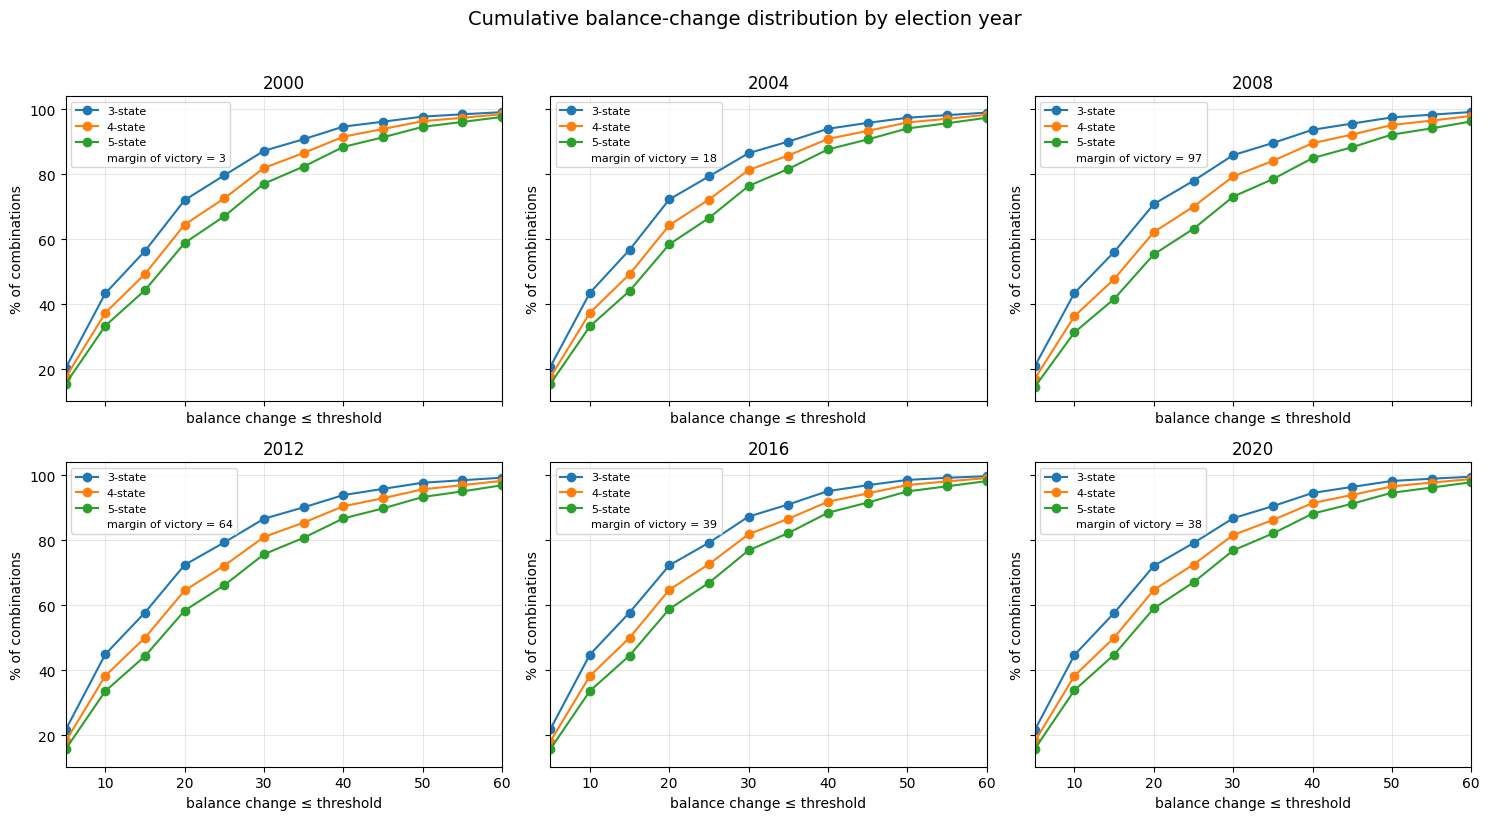

In [ ]:
import math
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# year -> margin of victory, from merged_df
vtw_map = merged_df.set_index('YEAR')['VOTES_TO_WIN'].to_dict()

years_present = sorted(summary['YEAR'].unique())
n = len(years_present)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows), sharex=True, sharey=True)
axes = np.atleast_1d(axes).ravel()

for ax, year in zip(axes, years_present):
    s = summary[summary['YEAR'] == year]
    for size in sorted(s['size'].unique()):
        sd = s[s['size'] == size].sort_values('threshold')
        ax.plot(sd['threshold'], sd['pct'], marker='o', label=f'{size}-state')

    # add margin of victory as a legend entry only (no line on the plot)
    handles, labels = ax.get_legend_handles_labels()
    vtw = vtw_map.get(year)
    if vtw is not None:
        handles.append(Line2D([], [], linestyle='none'))   # invisible handle
        labels.append(f'margin of victory = {vtw:.0f}')

    ax.set_title(f'{year}')
    ax.grid(True, alpha=0.3)
    ax.legend(handles, labels, fontsize=8)

for ax in axes[n:]:
    ax.set_visible(False)
for ax in axes[:n]:
    ax.set_xlabel('balance change ≤ threshold')
    ax.set_ylabel('% of combinations')

axes[0].set_xlim(summary['threshold'].min(), 60)   # x-axis reset to 60

fig.suptitle('Cumulative balance-change distribution by election year', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('balance_change_by_year.png', dpi=150, bbox_inches='tight')
plt.show()